In [10]:
import numpy as np
import matplotlib.pyplot as plt

class MLP:
    """
    Classe para implementação de uma Rede Neural Multicamada (MLP)
    Arquitetura: 2-3-3-1 (2 entradas, 3 neurônios na primeira camada,
    3 neurônios na segunda camada, 1 saída)
    """

    def __init__(self, learning_rate=0.1):
        """
        Inicializa a MLP com os parâmetros especificados

        Parâmetros:
            - learning_rate: taxa de aprendizado (padrão = 0.1)
        """
        self.learning_rate = learning_rate

        # Inicialização dos pesos e bias para cada camada
        # Camada 1: entrada (2) -> oculta (3)
        self.W1 = np.random.normal(0, 0.5, (2, 3))
        self.b1 = np.random.normal(0, 0.5, (1, 3))

        # Camada 2: oculta (3) -> oculta (3)
        self.W2 = np.random.normal(0, 0.5, (3, 3))
        self.b2 = np.random.normal(0, 0.5, (1, 3))

        # Camada 3: oculta (3) -> saída (1)
        self.W3 = np.random.normal(0, 0.5, (3, 1))
        self.b3 = np.random.normal(0, 0.5, (1, 1))

        # Armazenar histórico de erros para análise
        self.errors = []
    
    def sigmoid(self, x):
        """
        Função de ativação Sigmoid

        Parâmetros:
            - x: valor ou vetor para aplicar a função sigmoid

        Retorna:
            - Valor transformado pela função sigmoid
        """
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        """
        Derivada da função de ativação Sigmoid

        Parâmetros:
            - x: valor ou vetor (resultado da sigmoid)

        Retorna:
            - Derivada da função sigmoid aplicada a x
        """
        return x * (1 - x)

    def forward(self, X):
        """
        Passo forward da rede neural

        Parâmetros:
            - X: dados de entrada (batch_size x 2)

        Retorna:
            - y_pred: previsão da rede para os dados de entrada
        """
        # Camada 1: entrada -> primeira camada oculta (3 neurônios)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        # Camada 2: primeira camada oculta -> segunda camada oculta (3 neurônios)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)

        # Camada 3: segunda camada oculta -> saída (1 neurônio)
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.y_pred = self.sigmoid(self.z3)

        return self.y_pred
    
    def backward(self, X, y):
        """
        Passo backward (backpropagation) para calcular os gradientes e atualizar os pesos

        Parâmetros:
            - X: dados de entrada (batch_size x 2)
            - y: valores alvo (batch_size x 1)
        """
        # Cálculo do erro da saída
        output_error = self.y_pred - y

        # Gradientes para a camada 3 (saída)
        delta_output = output_error * self.sigmoid_derivative(self.y_pred)

        # Atualização dos pesos e bias da camada 3
        dW3 = np.dot(self.a2.T, delta_output)
        db3 = np.sum(delta_output, axis=0, keepdims=True)

        # Cálculo do erro para a camada 2
        error_layer2 = np.dot(delta_output, self.W3.T)
        delta_layer2 = error_layer2 * self.sigmoid_derivative(self.a2)

        # Atualização dos pesos e bias da camada 2
        dW2 = np.dot(self.a1.T, delta_layer2)
        db2 = np.sum(delta_layer2, axis=0, keepdims=True)

        # Cálculo do erro para a camada 1
        error_layer1 = np.dot(delta_layer2, self.W2.T)
        delta_layer1 = error_layer1 * self.sigmoid_derivative(self.a1)

        # Atualização dos pesos e bias da camada 1
        dW1 = np.dot(X.T, delta_layer1)
        db1 = np.sum(delta_layer1, axis=0, keepdims=True)

        # Aplica a atualização dos pesos e biases (descida do gradiente)
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
    
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
    
    def train(self, X, y, epochs=1000):
        """
        Treina a rede neural por um número específico de épocas

        Parâmetros:
            - X: dados de entrada
            - y: valores alvo
            - epochs: número de épocas para treinamento
        """
        print("Iniciando treinamento da MLP...")
        print(f"Parâmetros: Learning Rate = {self.learning_rate}, Epochs = {epochs}")
        print("-" * 50)

        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Cálculo do erro (MSE - Mean Squared Error)
            error = np.mean((y_pred - y) ** 2)

            # Armazena o erro para análise
            self.errors.append(error)
            
            # Backward pass (backpropagation)
            self.backward(X, y)
            
            # Imprimir progresso a cada 100 épocas
            if (epoch + 1) % 100 == 0:
                print(f"Época {epoch + 1}: Erro = {error:.6f}")

        print(f"\nTreinamento concluído!")
        print(f"Erro final: {self.errors[-1]:.6f}")
    
    def predict(self, X):
        """
        Faz previsões com a rede neural treinada

        Parâmetros:
            - X: dados de entrada para previsão

        Retorna:
            - Previsões da rede neural
        """
        return self.forward(X)


In [11]:
def main():
    """
    Função principal que executa o treinamento e testes da MLP para resolver XOR
    """
    # Definição dos dados de entrada (problema XOR)
    X_xor = np.array([
        [0, 0],  # Entradas do problema XOR
        [0, 1],
        [1, 0],
        [1, 1]
    ])

    # Definição dos rótulos de saída (esperados)
    y_xor = np.array([
        [0],  # XOR(0,0) = 0
        [1],  # XOR(0,1) = 1
        [1],  # XOR(1,0) = 1
        [0]   # XOR(1,1) = 0
    ])

    print("Problema XOR - MLP com arquitetura 2-3-3-1")
    print("=" * 50)

    # Definição dos hiperparâmetros
    learning_rate = 1  # Taxa de aprendizado - ajustável (valores típicos: 0.1 a 2.0)
    epochs = 5000       # Número de épocas - ajustável

    print(f"Configuração do modelo:")
    print(f"- Taxa de aprendizado: {learning_rate}")
    print(f"- Número de épocas: {epochs}")
    print()

    # Criação e treinamento da MLP
    mlp = MLP(learning_rate=learning_rate)

    # Treinamento da rede
    mlp.train(X_xor, y_xor, epochs=epochs)

    # Fazendo previsões com os dados de treinamento
    predictions = mlp.predict(X_xor)

    print("\nResultados do treinamento:")
    print("-" * 30)

    # Exibindo resultados antes e depois da normalização (neste caso, os valores já são 0 ou 1)
    print("Entrada -> Saída Esperada -> Saída Prevista")
    print("-" * 45)

    for i in range(len(X_xor)):
        input_data = X_xor[i]
        expected = y_xor[i][0]
        predicted = predictions[i][0]

        print(f"{input_data} -> {expected} -> {int(predicted)}")

    # Avaliação do desempenho
    print(f"\nErro médio quadrático (MSE) final: {mlp.errors[-1]:.6f}")

    # Plotando o histórico de erros
    plt.figure(figsize=(10, 6))
    plt.plot(mlp.errors)
    plt.title('Histórico de Erro durante o Treinamento')
    plt.xlabel('Época')
    plt.ylabel('Erro (MSE)')
    plt.grid(True)
    plt.show()

    # Verificação da convergência
    mse_threshold = 0.01  # Limite de erro para considerar o treinamento concluído
    if mlp.errors[-1] < mse_threshold:
        print(f"\n✅ Treinamento concluído com sucesso!")
        print(f"Erro final ({mlp.errors[-1]:.6f}) está abaixo do limite de convergência ({mse_threshold})")
    else:
        print(f"\n⚠️ Treinamento pode não ter convergido completamente")
        print(f"Erro final: {mlp.errors[-1]:.6f}")


In [12]:
def test_different_configs():
    """
    Testa diferentes hiperparâmetros para mostrar o impacto nos resultados
    """
    print("\n" + "=" * 60)
    print("Teste com diferentes configurações de hiperparâmetros")
    print("=" * 60)

    # Dados do XOR (repetidos para manter a função independente)
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([[0], [1], [1], [0]])

    # Dicionário com as configurações a serem testadas
    configs = [
        {"learning_rate": 0.01, "epochs": 1000},
        {"learning_rate": 0.1,  "epochs": 1000},
        {"learning_rate": 1.0,  "epochs": 1000},
        {"learning_rate": 0.01, "epochs": 5000},
        {"learning_rate": 0.1,  "epochs": 5000},
        {"learning_rate": 1.0,  "epochs": 5000},
    ]

    for i, config in enumerate(configs):
        print(f"\n--- Configuração {i+1} ---")
        print(f" Taxa de aprendizado: {config['learning_rate']}")
        print(f" Épocas: {config['epochs']}")

        # Cria e treina um novo modelo MLP com a configuração atual
        mlp = MLP(learning_rate=config['learning_rate'])
        
        # Chama o método train, mas sem os prints internos para não poluir
        # (Para isso, teríamos que adicionar um parâmetro 'verbose=False' no método train)
        # Por simplicidade, vamos manter a chamada original que irá imprimir o progresso
        mlp.train(X_xor, y_xor, epochs=config['epochs'])

        # Faz a predição e verifica o erro final
        predictions = mlp.predict(X_xor)
        final_error = mlp.errors[-1]

        print(f"Erro Final: {final_error:.6f}")

        # Verificar se teve convergência
        if final_error < 0.01:
            print(" ✅ Convergiu para a solução")
        else:
            print(" ⚠️  Não convergiu completamente")


Problema XOR - MLP com arquitetura 2-3-3-1
Configuração do modelo:
- Taxa de aprendizado: 1
- Número de épocas: 5000

Iniciando treinamento da MLP...
Parâmetros: Learning Rate = 1, Epochs = 5000
--------------------------------------------------
Época 100: Erro = 0.249949
Época 200: Erro = 0.249928
Época 300: Erro = 0.249896
Época 400: Erro = 0.249837
Época 500: Erro = 0.249691
Época 600: Erro = 0.249171
Época 700: Erro = 0.246313
Época 800: Erro = 0.227411
Época 900: Erro = 0.187695
Época 1000: Erro = 0.172732
Época 1100: Erro = 0.131392
Época 1200: Erro = 0.012916
Época 1300: Erro = 0.003818
Época 1400: Erro = 0.002053
Época 1500: Erro = 0.001366
Época 1600: Erro = 0.001010
Época 1700: Erro = 0.000796
Época 1800: Erro = 0.000654
Época 1900: Erro = 0.000553
Época 2000: Erro = 0.000478
Época 2100: Erro = 0.000421
Época 2200: Erro = 0.000375
Época 2300: Erro = 0.000338
Época 2400: Erro = 0.000307
Época 2500: Erro = 0.000282
Época 2600: Erro = 0.000260
Época 2700: Erro = 0.000241
Época 2

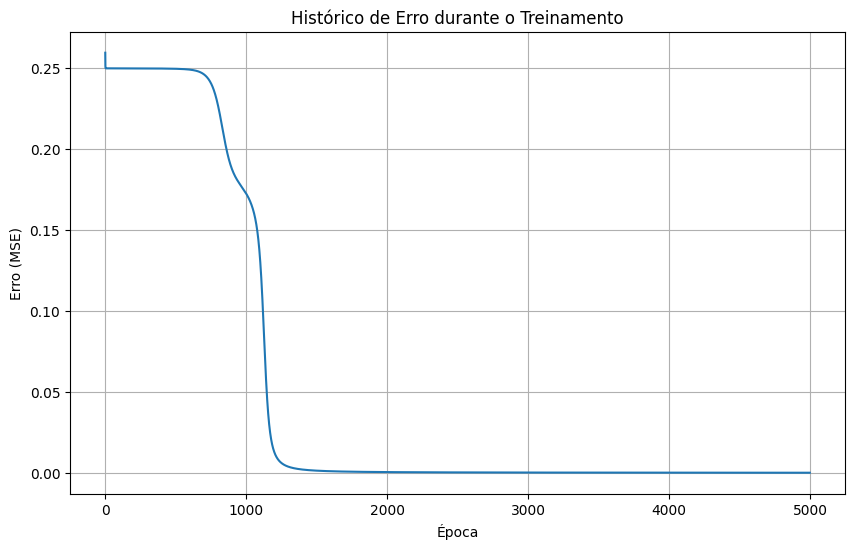


✅ Treinamento concluído com sucesso!
Erro final (0.000088) está abaixo do limite de convergência (0.01)


In [13]:
# Executar o treinamento principal
main()

In [14]:
# Testar diferentes configurações
test_different_configs()


Teste com diferentes configurações de hiperparâmetros

--- Configuração 1 ---
 Taxa de aprendizado: 0.01
 Épocas: 1000
Iniciando treinamento da MLP...
Parâmetros: Learning Rate = 0.01, Epochs = 1000
--------------------------------------------------
Época 100: Erro = 0.250560
Época 200: Erro = 0.250185
Época 300: Erro = 0.250049
Época 400: Erro = 0.250000
Época 500: Erro = 0.249981
Época 600: Erro = 0.249975
Época 700: Erro = 0.249972
Época 800: Erro = 0.249971
Época 900: Erro = 0.249970
Época 1000: Erro = 0.249969

Treinamento concluído!
Erro final: 0.249969
Erro Final: 0.249969
 ⚠️  Não convergiu completamente

--- Configuração 2 ---
 Taxa de aprendizado: 0.1
 Épocas: 1000
Iniciando treinamento da MLP...
Parâmetros: Learning Rate = 0.1, Epochs = 1000
--------------------------------------------------
Época 100: Erro = 0.250024
Época 200: Erro = 0.250022
Época 300: Erro = 0.250020
Época 400: Erro = 0.250019
Época 500: Erro = 0.250018
Época 600: Erro = 0.250017
Época 700: Erro = 0.250